In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

In [4]:
df = pd.read_csv('heart.csv')

# Drops 'thal' column
df = df.drop(columns=['thal'])
# Count rows before filtering
rows_before = len(df['ca'])
# Filter rows where 'ca' is 0, 1, 2, or 3
df_filtered = df[df['ca'].isin([0, 1, 2, 3])]
# Count rows after filtering
rows_after = len(df_filtered)
# Print number of rows dropped
print('Rows dropped:', rows_before - rows_after)

df = df_filtered
print(df.count())


Rows dropped: 5
age         298
sex         298
cp          298
trestbps    298
chol        298
fbs         298
restecg     298
thalach     298
exang       298
oldpeak     298
slope       298
ca          298
target      298
dtype: int64


In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,1


### Outlier Detection & Extreme Values

Box Plots for Continous variables: These continuous variables are most likely to have outliers. Box plots clearly show outliers as points beyond the whiskers.

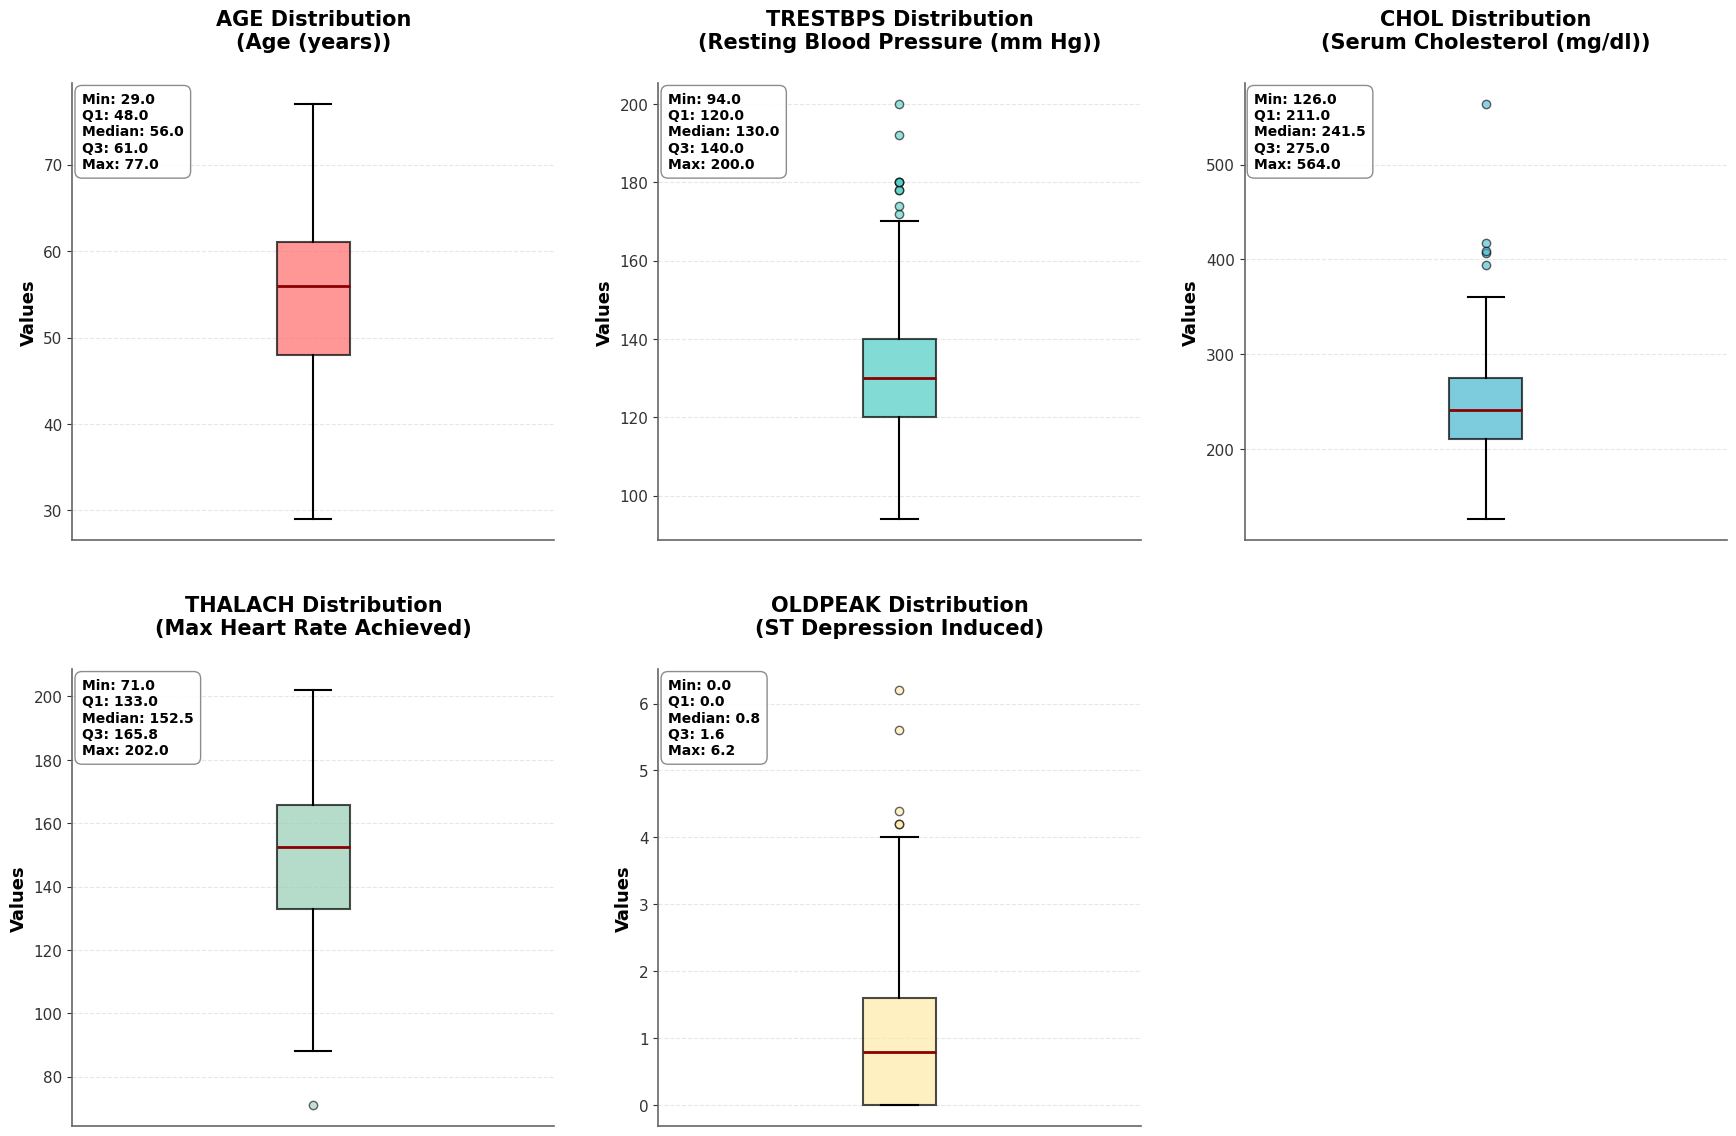

In [6]:
# Continuous variables
continuous_vars = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Variable descriptions for better interpretation
var_descriptions = {
    'age': 'Age (years)',
    'trestbps': 'Resting Blood Pressure (mm Hg)',
    'chol': 'Serum Cholesterol (mg/dl)',
    'thalach': 'Max Heart Rate Achieved',
    'oldpeak': 'ST Depression Induced'
}

# Color palette (matching previous plots)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

# Calculate layout
n_vars = len(continuous_vars)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

# Create subplots with proper spacing
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten()

for i, var in enumerate(continuous_vars):
    if var in df.columns and i < len(axes):
        
        bp = axes[i].boxplot(df[var], 
                            patch_artist=True,
                            boxprops=dict(facecolor=colors[i % len(colors)], 
                                        alpha=0.7,
                                        edgecolor='black',
                                        linewidth=1.5),
                            medianprops=dict(color='darkred', linewidth=2),
                            whiskerprops=dict(color='black', linewidth=1.5),
                            capprops=dict(color='black', linewidth=1.5),
                            flierprops=dict(marker='o', 
                                          markerfacecolor=colors[i % len(colors)], 
                                          markersize=6, 
                                          alpha=0.6,
                                          markeredgecolor='black'))
        
        # Sets title and description
        title = f'{var.upper()} Distribution'
        if var in var_descriptions:
            title += f'\n({var_descriptions[var]})'
        
        axes[i].set_title(title, fontsize=15, fontweight='bold', pad=25)
        axes[i].set_ylabel('Values', fontsize=13, fontweight='semibold')
        axes[i].set_xlabel('')  # Remove x-axis label as it's not needed for single box plots
        
        # Computes statistics for the info box
        q1 = df[var].quantile(0.25)
        median = df[var].median()
        q3 = df[var].quantile(0.75)
        min_val = df[var].min()
        max_val = df[var].max()
        
        # Add statistics text box
        stats_text = f'Min: {min_val:.1f}\nQ1: {q1:.1f}\nMedian: {median:.1f}\nQ3: {q3:.1f}\nMax: {max_val:.1f}'
        axes[i].text(0.02, 0.98, stats_text, 
                    transform=axes[i].transAxes, 
                    fontsize=10, 
                    fontweight='semibold',
                    verticalalignment='top',
                    bbox=dict(boxstyle='round,pad=0.5', 
                             facecolor='white', 
                             edgecolor='gray',
                             alpha=0.9))
        
        # Add subtle grid for easier reading
        axes[i].grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
        axes[i].set_axisbelow(True)
        
        # Clean up the plot appearance
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)
        axes[i].spines['left'].set_color('#666666')
        axes[i].spines['bottom'].set_color('#666666')
        axes[i].spines['left'].set_linewidth(1.2)
        axes[i].spines['bottom'].set_linewidth(1.2)
        
        # Improve tick styling
        axes[i].tick_params(axis='both', which='major', labelsize=11, colors='#333333')
        
        # Remove x-axis ticks
        axes[i].set_xticks([])
        
    else:
        if i < len(axes):
            axes[i].text(0.5, 0.5, f'{var} not found\nin dataframe',
                        ha='center', va='center', transform=axes[i].transAxes,
                        fontsize=14, fontweight='bold', color='red')
            axes[i].set_title(f'{var.upper()} - Not Found', fontsize=15, fontweight='bold')

# Hide empty subplots
for i in range(n_vars, len(axes)):
    axes[i].set_visible(False)

# Adjust layout with proper spacing
plt.tight_layout(pad=3.0, h_pad=4.0, w_pad=3.0)
plt.show()

### Distribution Analysis
Histograms to Create:

All continuous variables: age, trestbps, chol, thalach, oldpeak
Why: Shows if distributions are normal, skewed, bimodal, etc. Critical for understanding if you need transformations.

Bar Charts to Create:

All categorical variables: sex, cp, fbs, restecg, exang, slope, ca, thal, target
Why: Shows frequency distributions and class imbalances.

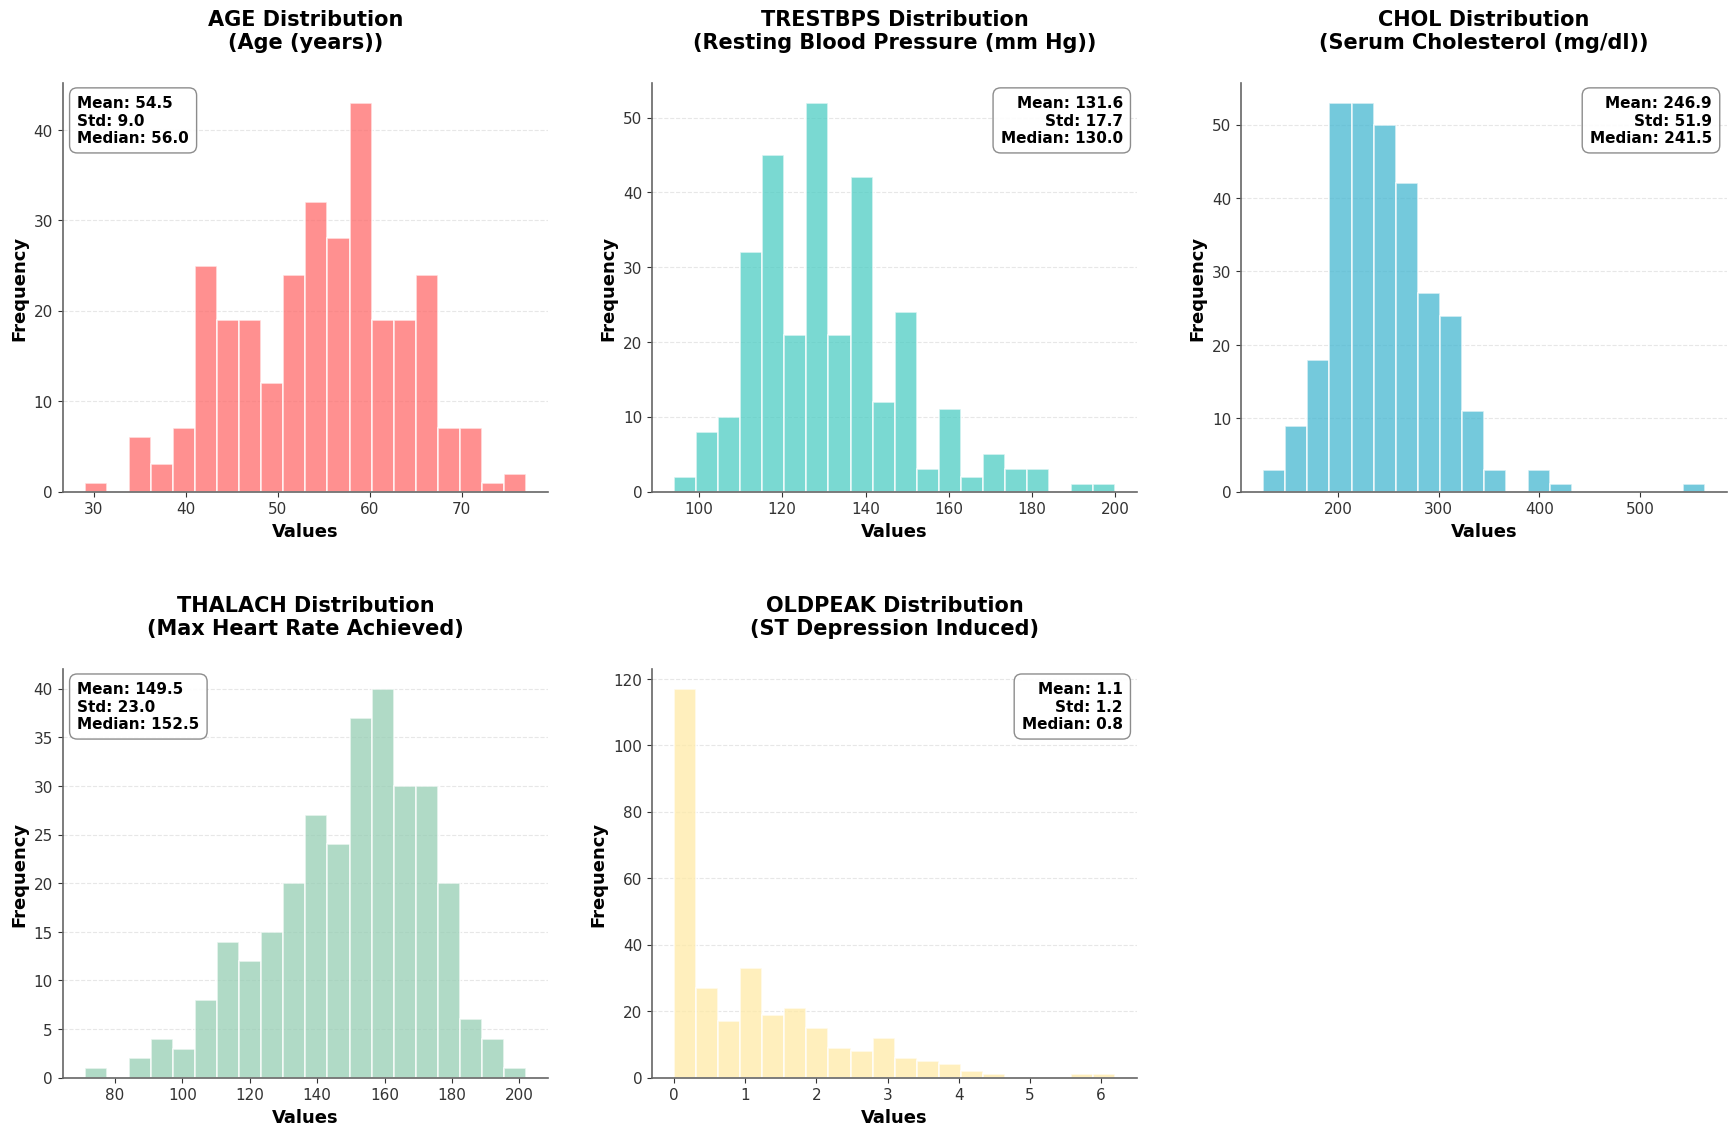

In [7]:
# Continuous variables
continuous_vars = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Variable descriptions for better interpretation
var_descriptions = {
    'age': 'Age (years)',
    'trestbps': 'Resting Blood Pressure (mm Hg)',
    'chol': 'Serum Cholesterol (mg/dl)',
    'thalach': 'Max Heart Rate Achieved',
    'oldpeak': 'ST Depression Induced'
}
# Color palette (matching the categorical plots)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']


n_vars = len(continuous_vars)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols
# Create subplots with proper spacing
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten()

for i, var in enumerate(continuous_vars):
    if var in df.columns:
       
        n, bins, patches = axes[i].hist(df[var], bins=20,
                                       color=colors[i % len(colors)],
                                       alpha=0.75,
                                       edgecolor='white',
                                       linewidth=1.2)
       
        # Sets title and description
        title = f'{var.upper()} Distribution'
        if var in var_descriptions:
            title += f'\n({var_descriptions[var]})'
       
        axes[i].set_title(title, fontsize=15, fontweight='bold', pad=25)
        axes[i].set_xlabel('Values', fontsize=13, fontweight='semibold')
        axes[i].set_ylabel('Frequency', fontsize=13, fontweight='semibold')
       
        # Calculate statistics
        mean_val = df[var].mean()
        std_val = df[var].std()
        median_val = df[var].median()
       
        # Find the best position for stats box to avoid covering bars
        # Get histogram data to find where bars are lowest
        hist_counts, hist_bins = np.histogram(df[var], bins=20)
        
        # Check if left side or right side has lower bars on average
        left_half_avg = np.mean(hist_counts[:len(hist_counts)//2])
        right_half_avg = np.mean(hist_counts[len(hist_counts)//2:])
        
        # Position stats box where there's less data
        if left_half_avg <= right_half_avg:
            # Place on top-left if left side has fewer bars
            x_pos, y_pos = 0.03, 0.97
            ha = 'left'
        else:
            # Place on top-right if right side has fewer bars  
            x_pos, y_pos = 0.97, 0.97
            ha = 'right'
        
        # Add statistics text box with better positioning
        stats_text = f'Mean: {mean_val:.1f}\nStd: {std_val:.1f}\nMedian: {median_val:.1f}'
        axes[i].text(x_pos, y_pos, stats_text,
                    transform=axes[i].transAxes,
                    fontsize=11,
                    fontweight='semibold',
                    verticalalignment='top',
                    horizontalalignment=ha,
                    bbox=dict(boxstyle='round,pad=0.5',
                             facecolor='white',
                             edgecolor='gray',
                             alpha=0.9))
       
        # Add subtle grid for easier reading
        axes[i].grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
        axes[i].set_axisbelow(True)
       
        # Clean up the plot appearance
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)
        axes[i].spines['left'].set_color('#666666')
        axes[i].spines['bottom'].set_color('#666666')
        axes[i].spines['left'].set_linewidth(1.2)
        axes[i].spines['bottom'].set_linewidth(1.2)
       
        # Improve tick styling
        axes[i].tick_params(axis='both', which='major', labelsize=11, colors='#333333')
       
    else:
        axes[i].text(0.5, 0.5, f'{var} not found\nin dataframe',
                    ha='center', va='center', transform=axes[i].transAxes,
                    fontsize=14, fontweight='bold', color='red')
        axes[i].set_title(f'{var.upper()} - Not Found', fontsize=15, fontweight='bold')

# Hide empty subplots
for i in range(n_vars, len(axes)):
    axes[i].set_visible(False)

# Adjust layout with proper spacing
plt.tight_layout(pad=3.0, h_pad=4.0, w_pad=3.0)
plt.show()

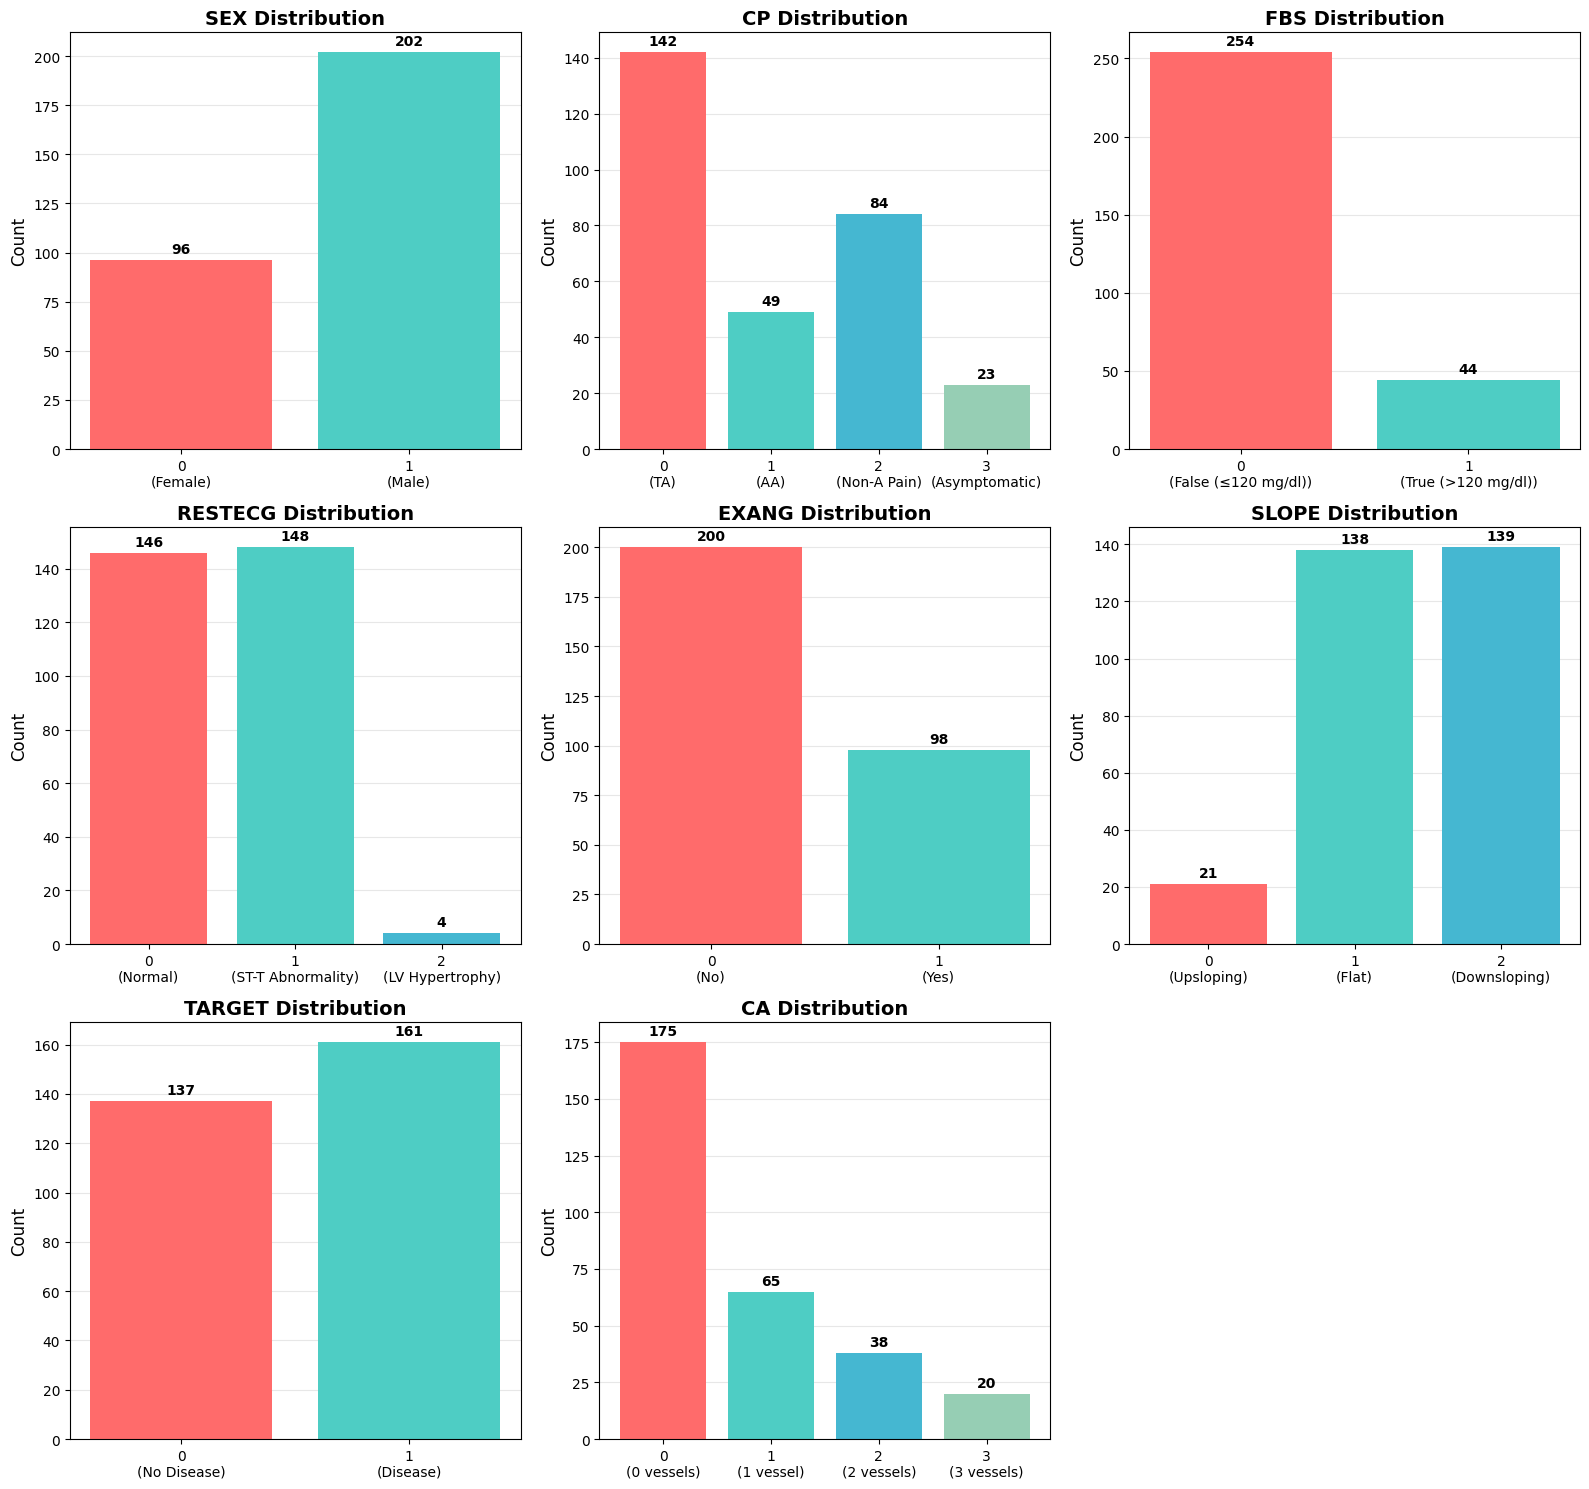

In [8]:
# Categorical variables to plot
categorical_vars = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'target', 'ca']

# Labels for better interpretation (common medical dataset meanings)
labels_dict = {
    'ca' : {0: '0 vessels', 1: '1 vessel', 2:'2 vessels', 3:'3 vessels'},
    'sex': {0: 'Female', 1: 'Male'},
    'cp': {0: 'TA', 1: 'AA', 2: 'Non-A Pain', 3: 'Asymptomatic'},
    'fbs': {0: 'False (≤120 mg/dl)', 1: 'True (>120 mg/dl)'},
    'restecg': {0: 'Normal', 1: 'ST-T Abnormality', 2: 'LV Hypertrophy'},
    'exang': {0: 'No', 1: 'Yes'},
    'slope': {0: 'Upsloping', 1: 'Flat', 2: 'Downsloping'},
    'target': {0: 'No Disease', 1: 'Disease'}
}

# Color palette
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8']

# Calculate number of rows and columns for subplots
n_vars = len(categorical_vars)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

# Create bar chart for each categorical variable
for i, var in enumerate(categorical_vars):
    if var in df.columns:
        # Count values and create bar chart
        counts = df[var].value_counts().sort_index()
        
        # Create bars with different colors
        bars = axes[i].bar(range(len(counts)), counts.values, 
                          color=[colors[j % len(colors)] for j in range(len(counts))])
        
        # Set title and labels
        axes[i].set_title(f'{var.upper()} Distribution', fontsize=14, fontweight='bold')
        axes[i].set_ylabel('Count', fontsize=12)
        
        # Set x-axis labels with meanings
        if var in labels_dict:
            tick_labels = [f"{idx}\n({labels_dict[var].get(idx, 'Unknown')})" 
                          for idx in counts.index]
            axes[i].set_xticks(range(len(counts)))
            axes[i].set_xticklabels(tick_labels, fontsize=10)
        else:
            axes[i].set_xticks(range(len(counts)))
            axes[i].set_xticklabels([str(idx) for idx in counts.index])
        
        # Add value labels on bars
        for j, (bar, v) in enumerate(zip(bars, counts.values)):
            axes[i].text(bar.get_x() + bar.get_width()/2, v + max(counts.values)*0.01, 
                        str(v), ha='center', va='bottom', fontweight='bold')
        
        # Add grid for easier reading
        axes[i].grid(axis='y', alpha=0.3)
        axes[i].set_axisbelow(True)
        
    else:
        axes[i].text(0.5, 0.5, f'{var} not found\nin dataframe', 
                    ha='center', va='center', transform=axes[i].transAxes)
        axes[i].set_title(f'{var.upper()} - Not Found')

# Hide empty subplots
for i in range(n_vars, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()



### Correlation Analysis
Correlation Heatmap to Create:

All numeric variables in one heatmap
Why: Quickly identifies which variables are related and potential multicollinearity issues.


In [9]:
# Get all numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Columns to exclude from the correlation heatmap
exclude_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
numeric_cols = [col for col in numeric_cols if col not in exclude_cols]
print("Numeric columns used in heatmap:", numeric_cols)
correlation_matrix = df[numeric_cols].corr()

Numeric columns used in heatmap: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'target']


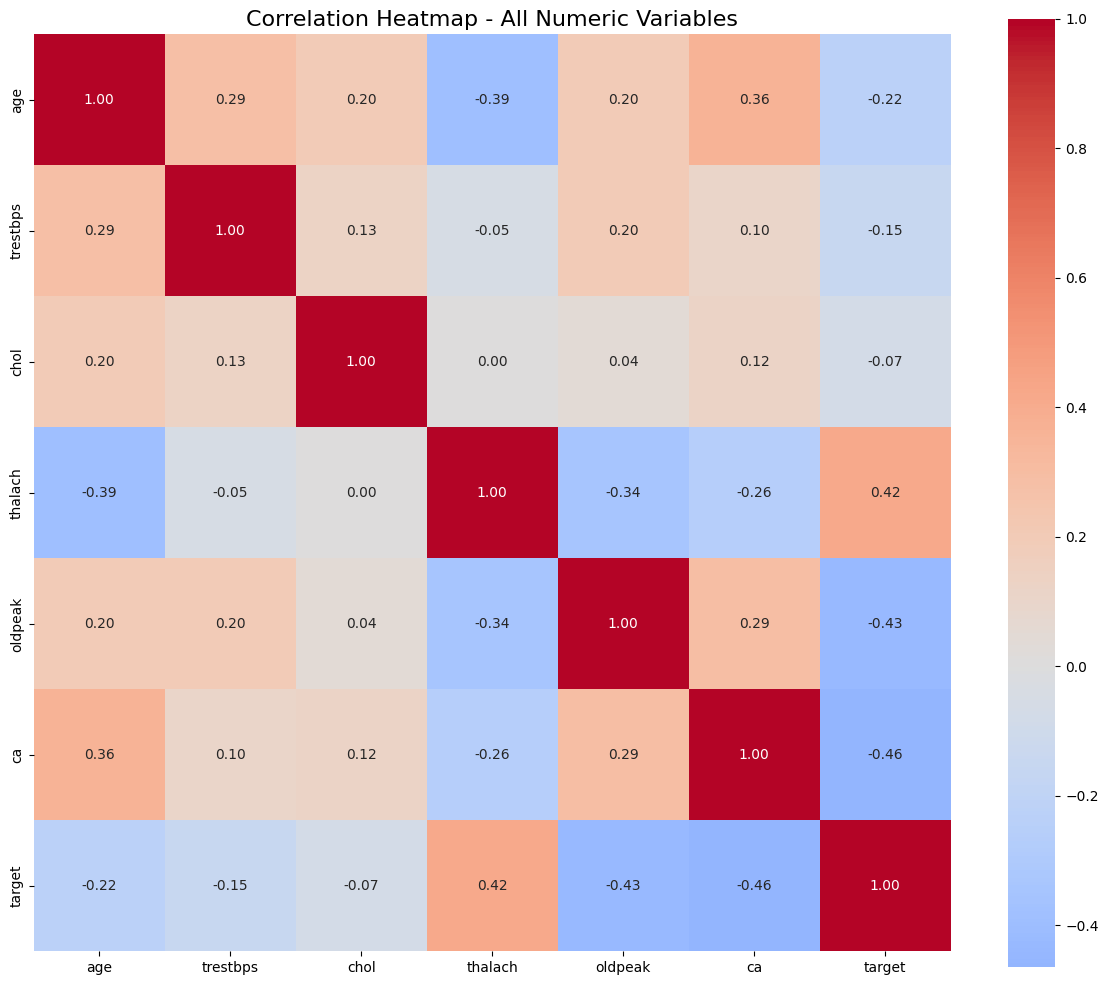

In [10]:
plt.figure(figsize=(12, 10))
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            fmt='.2f')
plt.title('Correlation Heatmap - All Numeric Variables', fontsize=16)
plt.tight_layout()
plt.show()

Quick Guide:

* Values range from -1 to +1
* +1 = perfect positive correlation (as one goes up, other goes up)
* -1 = perfect negative correlation (as one goes up, other goes down)
* 0 = no correlation
* Colors: Dark red = strong positive, Dark blue = strong negative, White = weak/no correlation

Best predictors of heart disease:
- thalach (max heart rate): +0.42 → Higher max heart rate = more likely disease  
- oldpeak: -0.43 → Higher ST depression = LESS likely disease


## PCA

In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


In [12]:
# Separate features and target
X = df.drop('target', axis=1)  # Features
y = df['target']               # Target variable

# Standardize the features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Get feature names for interpretation
feature_names = X.columns.tolist()
unique_classes = np.unique(y)

print("Dataset shape:", X.shape)
print("Features:", feature_names)
print("Target distribution:")
print(y.value_counts())

Dataset shape: (298, 12)
Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca']
Target distribution:
target
1    161
0    137
Name: count, dtype: int64


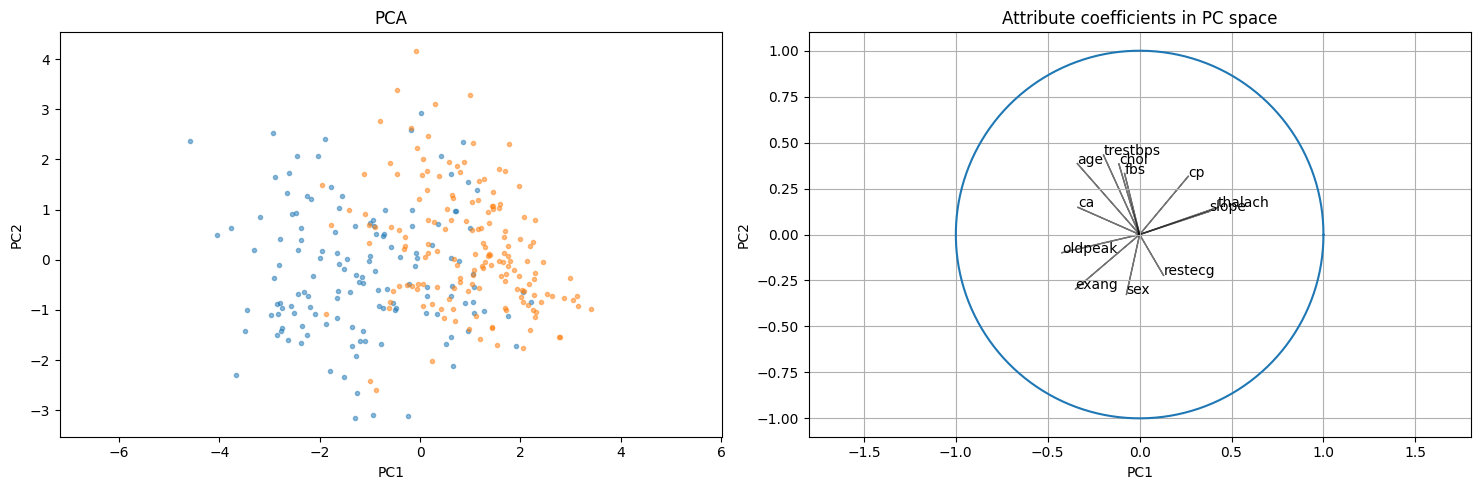

In [13]:
PC_idxs = [0, 1]  # Indices of the principal components to plot

# Fit and transform the data into B, extract the principal components, V
# Create PCA object
pca = PCA()
# Fit the PCA to the data and project to the principal components
B = pca.fit_transform(X_scaled)
# Get the principal components
V = pca.components_.T

# Make the plot
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
# Plot the data projected onto PC1/PC2
axs[0].set_title("PCA")
for fluid_type in unique_classes:
    mask = (y == fluid_type)
    axs[0].plot(B[mask, PC_idxs[0]], B[mask, PC_idxs[1]], ".", alpha=0.5, label=fluid_type)

axs[0].set_xlabel(f"PC{PC_idxs[0] + 1}")
axs[0].set_ylabel(f"PC{PC_idxs[1] + 1}")
axs[0].axis("equal")

# Plot attribute coefficients in principal component space
axs[1].set_title("Attribute coefficients in PC space")
for attr_idx, attr_name in enumerate(X.columns):
    # Plot an arrow for each attribute, add a label
    
    axs[1].arrow(0, 0, V[attr_idx, PC_idxs[0]], V[attr_idx, PC_idxs[1]], color='black', alpha=0.5)
    axs[1].text(V[attr_idx, PC_idxs[0]], V[attr_idx, PC_idxs[1]], attr_name)

    
axs[1].set_xlim([-1, 1])
axs[1].set_ylim([-1, 1])
axs[1].set_xlabel(f"PC{PC_idxs[0] + 1}")
axs[1].set_ylabel(f"PC{PC_idxs[1] + 1}")
axs[1].grid()
# Add a unit circle
axs[1].plot(np.cos(np.arange(0, 2 * np.pi, 0.01)), np.sin(np.arange(0, 2 * np.pi, 0.01)))
axs[1].axis("equal")

plt.tight_layout()
plt.show()


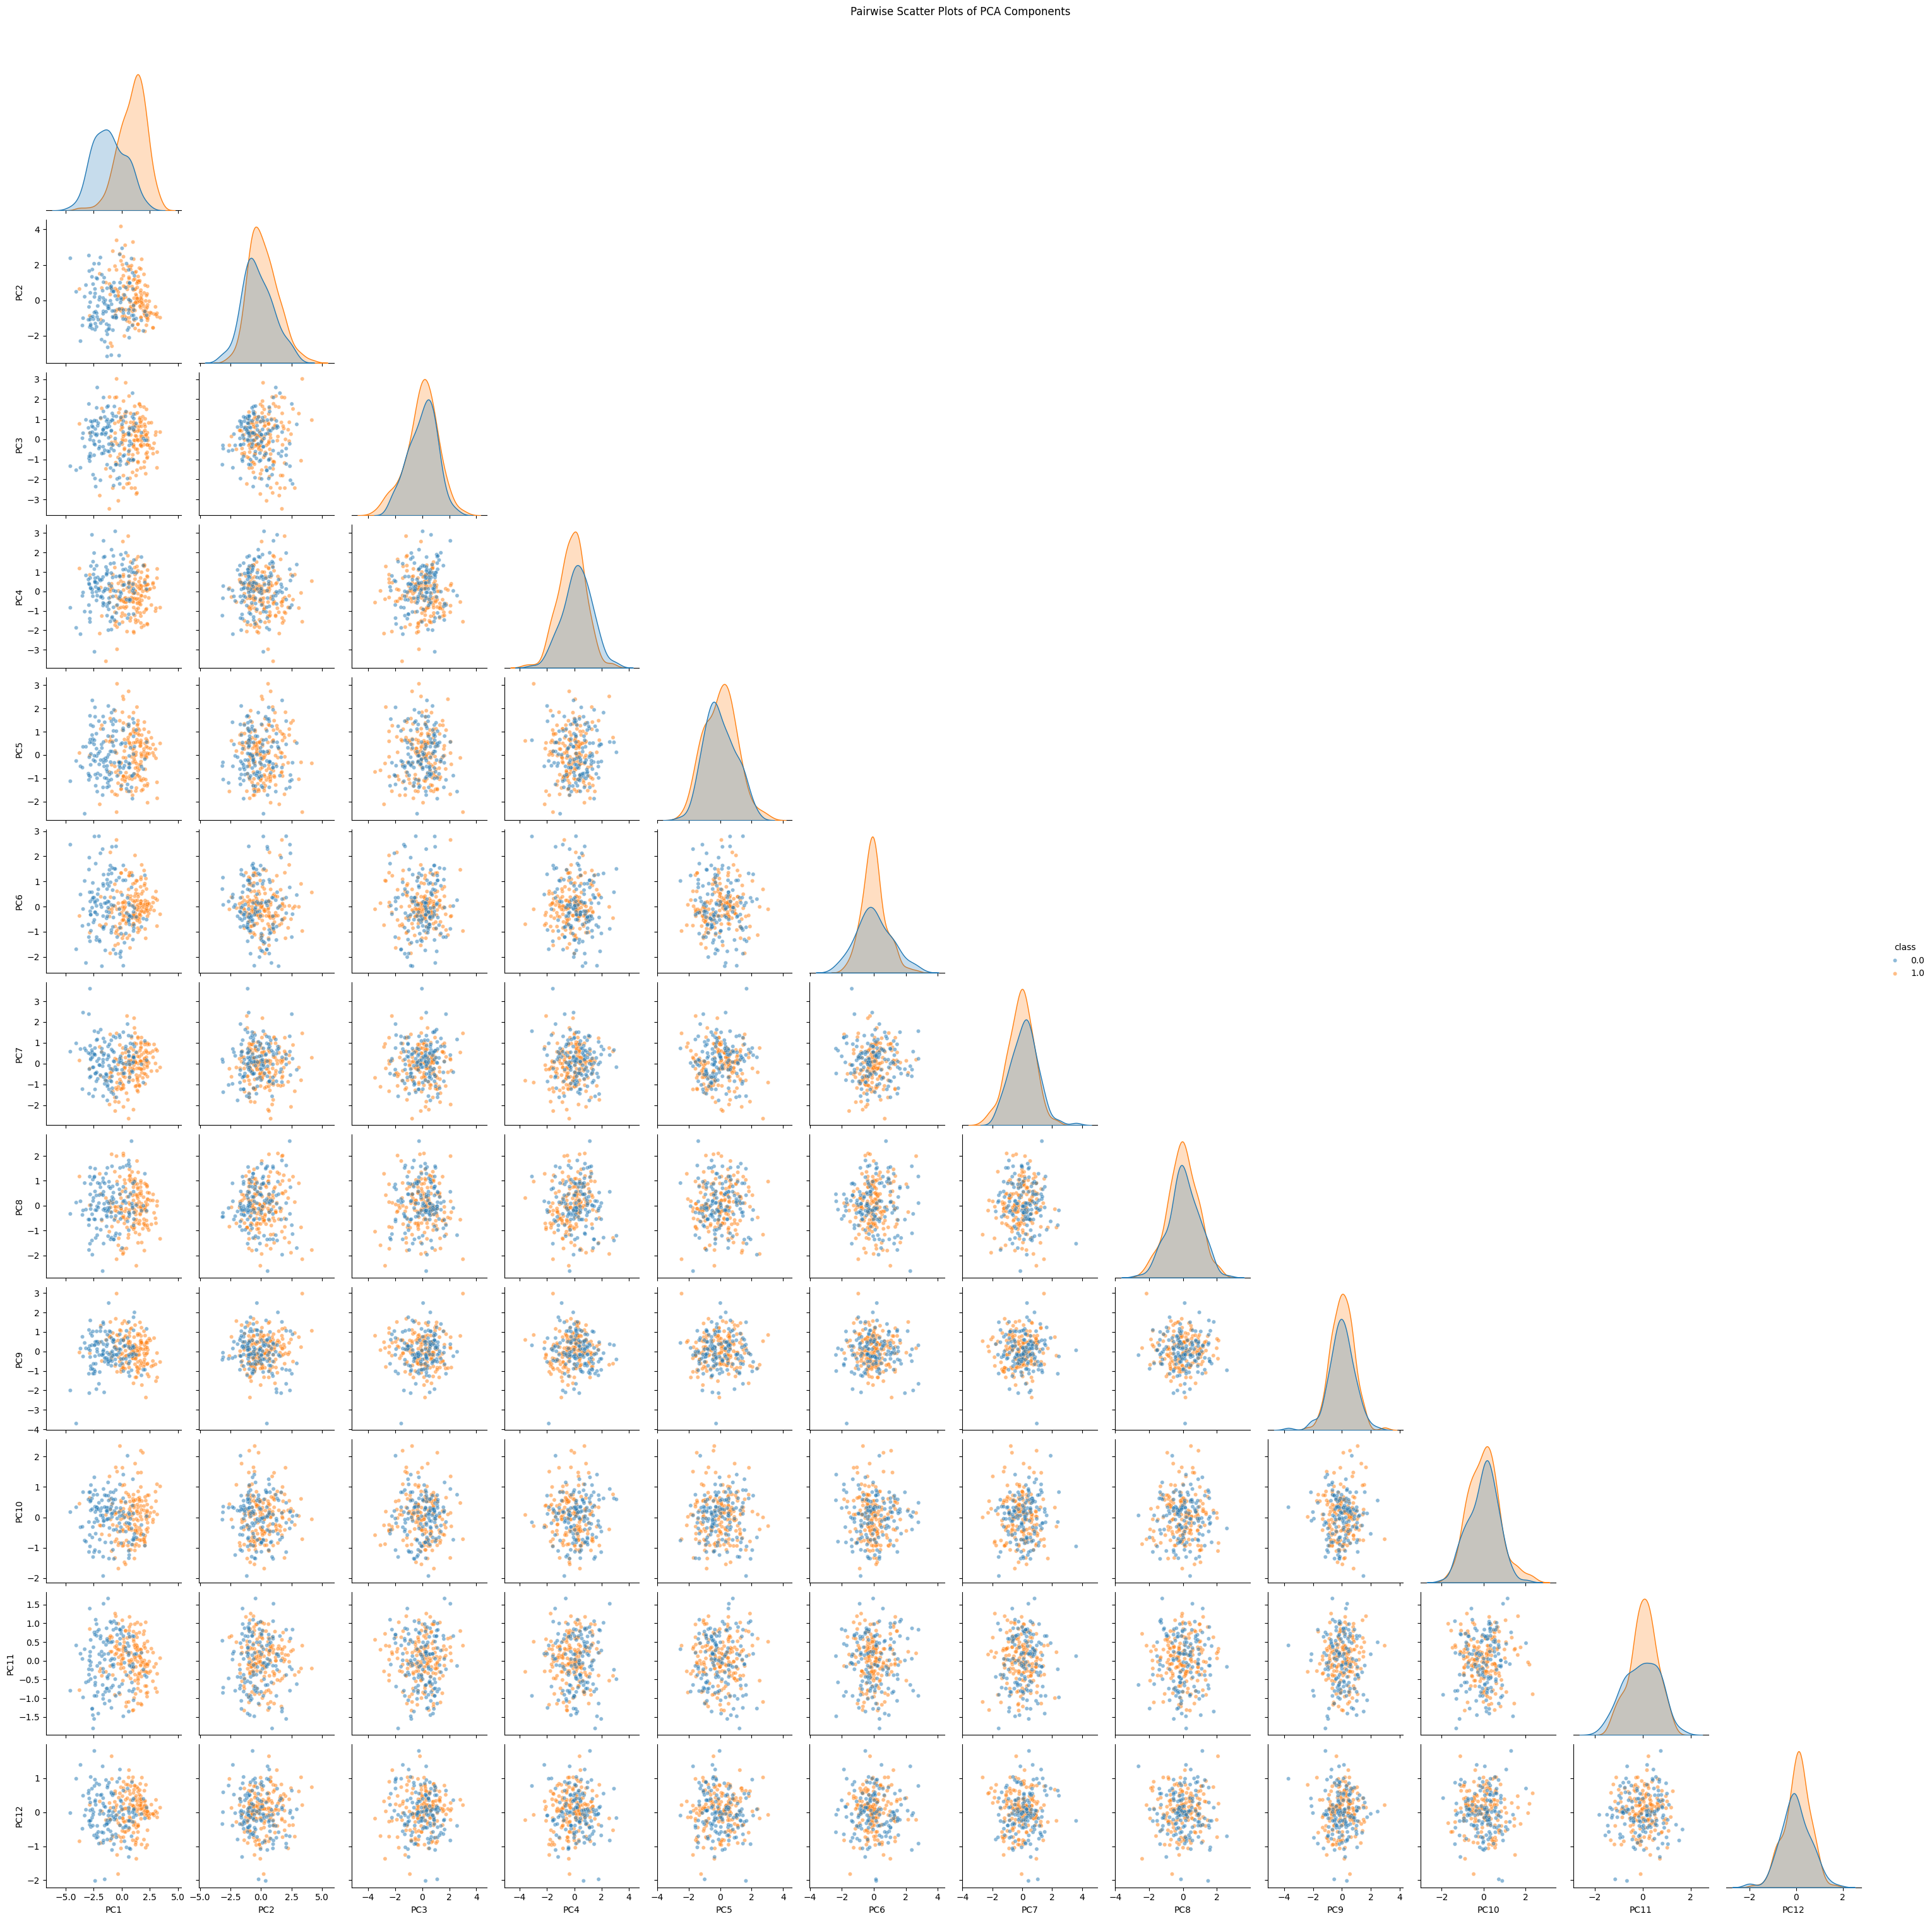

In [16]:
# Put PCA results into a DataFrame
df_pca = pd.DataFrame(B, columns=[f"PC{i+1}" for i in range(B.shape[1])])
df_pca["class"] = y

# Pairwise scatter plot, colored by class
sns.pairplot(
    df_pca,
    vars=[f"PC{i+1}" for i in range(B.shape[1])],  # all 8 PCs
    hue="class",       # color points by class
    diag_kind="kde",   # KDE plots on the diagonal
    corner=True,       # only show lower triangle
    plot_kws={"alpha": 0.5, "s": 20, "marker": "o"}  # control marker style
)

plt.suptitle("Pairwise Scatter Plots of PCA Components", y=1.02)
plt.show()

C:\Users\mauri\AppData\Local\Temp\ipykernel_24324\4059790625.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(feature_names, rotation=45)
C:\Users\mauri\AppData\Local\Temp\ipykernel_24324\4059790625.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(feature_names, rotation=45)


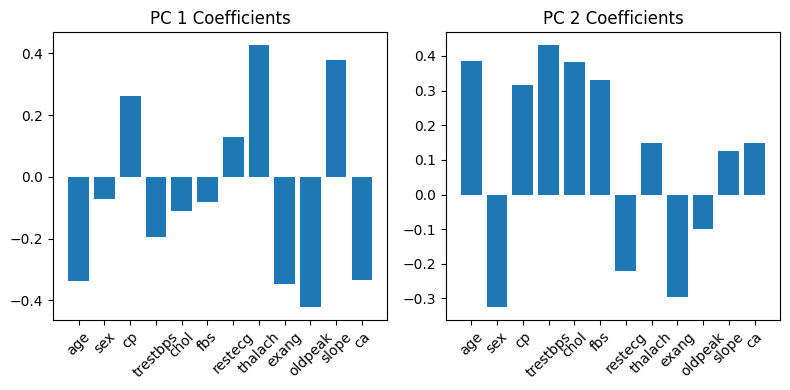

In [23]:
# YOUR CODE HERE
components = pca.components_
fig, axs = plt.subplots(1,2, figsize=(4*2, 4))
for i in range(2):
    axs[i].bar(feature_names, components[i])
    axs[i].set_title(f'PC {i+1} Coefficients')
    axs[i].set_xticklabels(feature_names, rotation=45)
plt.tight_layout()
plt.show()

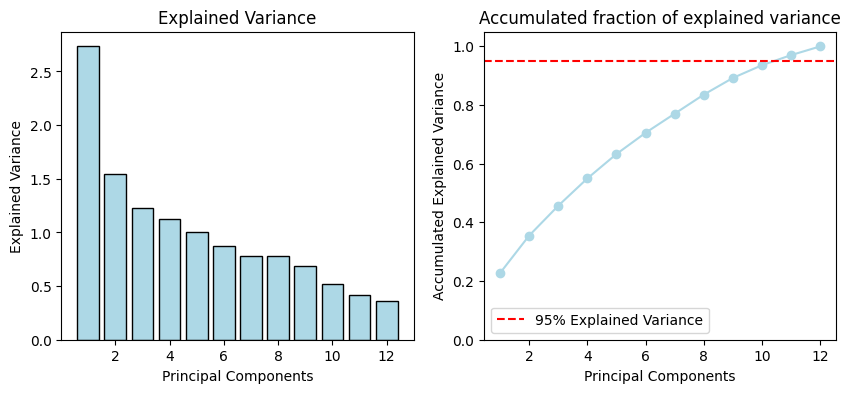

In [ ]:
# Explained variance plot
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].set_title('Explained Variance')
axs[0].set_xlabel('Principal Components')
axs[0].set_ylabel('Explained Variance')

# Bar plot for explained variance
explained_variance = pca.fit(X_scaled).explained_variance_
axs[0].bar(range(1, pca.n_components_  + 1), explained_variance, color='lightblue', edgecolor='black')

# Accumulated explained variance plot
axs[1].set_title('Accumulated fraction of explained variance')
axs[1].set_xlabel('Principal Components')
axs[1].set_ylabel('Accumulated Explained Variance')

accumulated_variance = pca.explained_variance_ratio_.cumsum()
axs[1].plot(range(1, pca.n_components_  + 1), accumulated_variance, marker='o', color='lightblue')
axs[1].set_ylim(0, 1.05)
# Horizontal line at 95% explained variance
axs[1].axhline(y=0.95, color='r', linestyle='--', label='95% Explained Variance')
axs[1].legend()
plt.show()